# How to use the DeepFMMatcher

The `DeepFMMatcher` takes a hybrid approach between classical functional maps and learning-based methods.
Instead of optimizing with hand-crafted descriptors, or training across a dataset, it runs
**gradient descent on a single shape pair**: a deep FM model (feature extractor + functional map
solver) is jointly optimized from scratch using unsupervised spectral losses.

The optimization loop is identical to the learning stage:
```
model.forward() → LossManager.compute_loss() → loss.backward()
```
This means **any `BaseModel` and any loss from `geomfum.learning.losses` can be plugged in**.

In [1]:
import os

os.environ["GEOMSTATS_BACKEND"] = "pytorch"

import gsops.backend as gs  # noqa: E402
import torch

from geomfum.dataset import NotebooksDataset
from geomfum.matcher import DeepFMMatcher
from geomfum.shape import TriangleMesh

[Load meshes](00_load_mesh_from_file.ipynb) and compute their [spectral basis](02_mesh_laplacian_spectrum.ipynb).

In [2]:
dataset = NotebooksDataset()

mesh_a = TriangleMesh.from_file(dataset.get_filename("faust-00"))
mesh_b = TriangleMesh.from_file(dataset.get_filename("faust-04"))

mesh_a.laplacian.find_spectrum(spectrum_size=200, set_as_basis=True)
mesh_b.laplacian.find_spectrum(spectrum_size=200, set_as_basis=True)

mesh_a.n_vertices, mesh_b.n_vertices

INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\faust-00.off').
INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\faust-04.off').
c:\Users\giuli\OneDrive\Research\geomfum_proj\venv\Lib\site-packages\gsops\pytorch\sparse.py:21: UserWarning: Sparse CSC tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  return _torch.sparse_csc_tensor(ccol_indices, row_indices, values, size=array.shape)


(6890, 6890)

In [3]:
# move to cuda for a faster optimization
device = "cuda" if torch.cuda.is_available() else "cpu"


def move_to_device(shape, device):
    """Move the shape to the appropriate device (GPU if available, otherwise CPU)."""
    shape.vertices = gs.to_device(shape.vertices, device)
    shape.basis.full_vals = gs.to_device(shape.basis.full_vals, device)
    shape.basis.full_vecs = gs.to_device(shape.basis.full_vecs, device)
    shape.laplacian._mass_matrix = gs.to_device(shape.laplacian._mass_matrix, device)

    # Only move faces to device for meshes
    if shape.shape_type == "mesh":
        shape.faces = gs.to_device(shape.faces, device)
    return shape


mesh_a = move_to_device(mesh_a, device)
mesh_b = move_to_device(mesh_b, device)

## Basic usage

With defaults the matcher uses `FMNet` (random DiffusionNet weights) and a
`LossManager` combining orthonormality + bijectivity + spectral descriptor preservation.

In [4]:
matcher = DeepFMMatcher(fmap_size=30, n_iters=1, lr=1e-3)
result = matcher(mesh_a, mesh_b)

print(f"p2p21 shape : {result.p2p21.shape}")
print(f"fmap12 shape: {result.fmap12.shape}")

p2p21 shape : torch.Size([6890])
fmap12 shape: torch.Size([30, 30])


Since the default solver is bijective, `fmap21` and `p2p12` are also available.

In [5]:
print(f"fmap21 shape: {result.fmap21.shape}")
print(f"p2p12 shape : {result.p2p12.shape}")

fmap21 shape: torch.Size([30, 30])
p2p12 shape : torch.Size([6890])


## Monitoring convergence

`verbose=True` prints each loss component individually every 100 iterations.

In [6]:
matcher = DeepFMMatcher(fmap_size=30, n_iters=1, lr=1e-3, verbose=True)
result = matcher(mesh_a, mesh_b)

  iter    0 | OrthonormalityLoss=92.2990  BijectivityLoss=45.0380


## Visualising the functional map

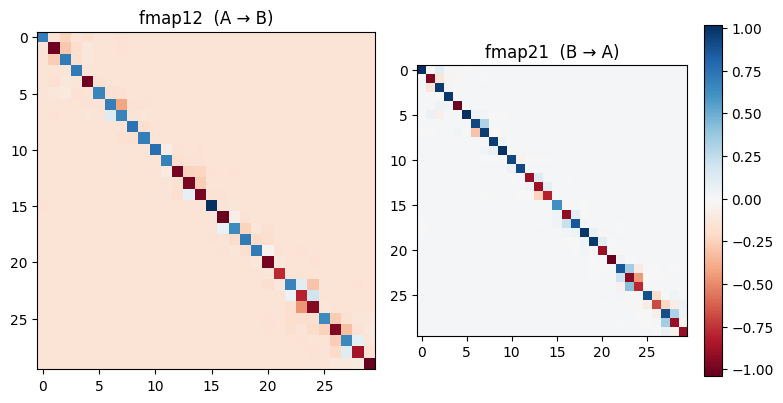

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(result.fmap12.detach().cpu().numpy(), cmap="RdBu")
axes[0].set_title("fmap12  (A → B)")
axes[1].imshow(result.fmap21.detach().cpu().numpy(), cmap="RdBu")
axes[1].set_title("fmap21  (B → A)")
plt.colorbar(axes[1].images[0], ax=axes[1])
plt.tight_layout()

## Custom loss and models

Because the loop reuses `LossManager` from the learning stage, any loss from
`geomfum.learning.losses` can be composed here with arbitrary weights.

In [ ]:
from geomfum.descriptor.learned import FeatureExtractor
from geomfum.descriptor.spectral import WaveKernelSignature
from geomfum.forward_functional_map import ForwardFunctionalMap
from geomfum.learning.losses import BijectivityLoss, LossManager, OrthonormalityLoss
from geomfum.learning.models import FMNet

loss_manager = LossManager(
    [
        OrthonormalityLoss(weight=1.0),
        BijectivityLoss(weight=1.0),
    ]
)
feature_extractor = FeatureExtractor.from_registry(
    which="diffusionnet",
    device="cuda",
    in_channels=128,
    descriptor=WaveKernelSignature(n_domain=128, k=201),
    out_channels=128,
    n_block=2,
)
fmap_module = ForwardFunctionalMap(1e3, 1, True, fmap_shape=(30, 30))
functional_map_model = FMNet(
    feature_extractor=feature_extractor,
    fmap_module=fmap_module,
)

matcher = DeepFMMatcher(
    fmap_size=30,
    n_iters=1,
    loss_manager=loss_manager,
    model=functional_map_model,
    verbose=True,
)

result = matcher(mesh_a, mesh_b)
result.p2p21.shape

Requested k=201 is larger than the number of eigenvalues currently in use (spectrum_size=201). Recomputing basis with k=201.
Requested k=201 is larger than the number of eigenvalues currently in use (spectrum_size=201). Recomputing basis with k=201.
  iter    0 | OrthonormalityLoss=31.1468  BijectivityLoss=30.8660
  iter   99 | OrthonormalityLoss=4.6643  BijectivityLoss=1.4427


torch.Size([6890])

## Further reading

* [How to use deep functional map models (FMNet, RobustFMNet)?](./14_deep_functional_maps_models.ipynb)
* [How to compute a functional map (classical)?](./07_functional_map.ipynb)
* [How to use the forward (differentiable) functional map solver?](./08_functional_map_forward.ipynb)
* [How to use other matchers?](./19_matchers.ipynb)